In [18]:
# ============================================================
# 07_model_explainability.ipynb
# Purpose:
#   Explain the production champion model and its base drivers.
#
# Focus:
#   - global feature importance
#   - SHAP explanations
#   - applicant-level reason codes
#   - ensemble interpretability
#   - governance-ready outputs
# ============================================================

import json
import joblib
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Setup complete.")

Setup complete.


In [2]:
# ============================================================
# Paths
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR = OUTPUT_DIR / "saved_models"
CONFIG_DIR = OUTPUT_DIR / "model_configs"
REPORT_DIR = OUTPUT_DIR / "reports"

SCORING_OUTPUT_DIR = OUTPUT_DIR / "production_scoring"
EXPLAINABILITY_OUTPUT_DIR = OUTPUT_DIR / "explainability"

BASE_MODEL_DIR = MODEL_DIR / "base_models"
ENSEMBLE_MODEL_DIR = MODEL_DIR / "ensemble_models"

EXPLAINABILITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)
print("Output Directory:", OUTPUT_DIR)
print("Explainability Output Directory:", EXPLAINABILITY_OUTPUT_DIR)

Project Root: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Output Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs
Explainability Output Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/explainability


In [3]:
# ============================================================
# Load Production Scored Data
# ============================================================

scored_test = pd.read_csv(SCORING_OUTPUT_DIR / "cs_test_scored_final_output.csv")

print("Scored production data:", scored_test.shape)
display(scored_test.head())

production_model_id = scored_test["production_model_id"].iloc[0]

print("Production model:", production_model_id)

Scored production data: (101503, 12)


,applicant_id,production_model_id,production_pd,risk_percentile,risk_band,recommended_action,BAYSTACK004_pd,BAYSTACK002_pd,WASTACK003_pd,XGBSTACK004_pd,LGB002_pd,challenger_delta
0,1,BAYSTACK004,0.067094,0.754037,Medium Risk,Standard Review,0.067094,0.065838,0.068121,0.065108,0.069071,0.001256
1,2,BAYSTACK004,0.052869,0.704058,Medium Risk,Standard Review,0.052869,0.051872,0.053764,0.055243,0.054612,0.000997
2,3,BAYSTACK004,0.013833,0.360561,Low Risk,Auto Approve,0.013833,0.013514,0.012889,0.010152,0.012221,0.000319
3,4,BAYSTACK004,0.071192,0.766174,Medium Risk,Standard Review,0.071192,0.077750,0.070415,0.065775,0.069996,-0.006559
4,5,BAYSTACK004,0.110356,0.852694,High Risk,Enhanced Review,0.110356,0.113619,0.107548,0.097498,0.105707,-0.003264


Production model: BAYSTACK004


In [4]:
# ============================================================
# Load Champion / Base Model Artifacts
# ============================================================

# Production champion ensemble payload
champion_payload = joblib.load(ENSEMBLE_MODEL_DIR / f"{production_model_id}.joblib")

print("Champion ensemble loaded:")
print(champion_payload["ensemble_id"])
print(champion_payload["ensemble_name"])
print(champion_payload["base_models"])

# Load key base models
base_model_ids = champion_payload["base_models"]

base_models = {}

for model_id in base_model_ids:
    model_path = BASE_MODEL_DIR / f"{model_id}.joblib"

    if not model_path.exists():
        raise FileNotFoundError(f"Missing base model: {model_path}")

    base_models[model_id] = joblib.load(model_path)
    print(f"Loaded base model: {model_id}")

Champion ensemble loaded:
BAYSTACK004
Top 2 Bayesian Ensemble
['LGB002', 'CAT005']
Loaded base model: LGB002
Loaded base model: CAT005


In [5]:
# ============================================================
# Load Scoring Handoff / Feature Metadata
# ============================================================

SCORING_HANDOFF_DIR = OUTPUT_DIR / "scoring_handoff"
PREPROCESSING_DIR = OUTPUT_DIR / "preprocessing_artifacts"

with open(SCORING_HANDOFF_DIR / "base_model_features.json", "r") as f:
    base_model_features = json.load(f)

with open(PREPROCESSING_DIR / "preprocessing_handoff.json", "r") as f:
    preprocessing_handoff = json.load(f)

print("Feature metadata loaded.")

for model_id in base_model_ids:
    print(model_id, "features:", len(base_model_features[model_id]))

Feature metadata loaded.
LGB002 features: 15
CAT005 features: 15


In [6]:
# ============================================================
# Load Raw Production Data
# ============================================================

df_test_raw = pd.read_csv(DATA_DIR / "cs-test.csv")

ID_COL = "Unnamed: 0"
TARGET = "SeriousDlqin2yrs"

applicant_id = df_test_raw[ID_COL].copy()

drop_cols = [c for c in [ID_COL, TARGET] if c in df_test_raw.columns]

df_test_features_raw = df_test_raw.drop(columns=drop_cols)

print("Raw production feature data:", df_test_features_raw.shape)
display(df_test_features_raw.head())

Raw production feature data: (101503, 10)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [7]:
# ============================================================
# Recreate Tree Engineered Features
# ============================================================

tree_features = preprocessing_handoff["tree_features"]

df_test_prep = df_test_features_raw.copy()

# Missing flags
df_test_prep["MonthlyIncome_missing_flag"] = df_test_prep["MonthlyIncome"].isna().astype(int)
df_test_prep["NumberOfDependents_missing_flag"] = df_test_prep["NumberOfDependents"].isna().astype(int)

# Median imputation
df_test_prep["MonthlyIncome_median"] = df_test_prep["MonthlyIncome"].fillna(
    df_test_prep["MonthlyIncome"].median()
)

df_test_prep["NumberOfDependents_median"] = df_test_prep["NumberOfDependents"].fillna(
    df_test_prep["NumberOfDependents"].median()
)

# Flags / transforms
df_test_prep["DebtRatio_high_flag"] = (df_test_prep["DebtRatio"] > 1).astype(int)

df_test_prep["age_sq"] = df_test_prep["age"] ** 2

df_test_prep["DebtRatio_log"] = np.log1p(
    df_test_prep["DebtRatio"].clip(lower=0)
)

df_test_prep["RevolvingUtilization_log"] = np.log1p(
    df_test_prep["RevolvingUtilizationOfUnsecuredLines"].clip(lower=0)
)

df_test_prep["RevolvingUtilization_high_flag"] = (
    df_test_prep["RevolvingUtilizationOfUnsecuredLines"] > 1
).astype(int)

missing_tree_cols = [c for c in tree_features if c not in df_test_prep.columns]

if missing_tree_cols:
    raise KeyError(f"Missing tree feature columns: {missing_tree_cols}")

X_test_tree = df_test_prep[tree_features].copy()

print("X_test_tree:", X_test_tree.shape)
display(X_test_tree.head())

X_test_tree: (101503, 15)


,age,age_sq,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents_median,NumberOfDependents_missing_flag,MonthlyIncome_median,MonthlyIncome_missing_flag,DebtRatio_log,DebtRatio_high_flag,RevolvingUtilization_log,RevolvingUtilization_high_flag
0,43,1849,0,0,0,4,0,0.0,0,5700.0,0,0.163404,0,0.634203,0
1,57,3249,0,0,0,15,4,2.0,0,9141.0,0,0.423460,0,0.380691,0
2,59,3481,0,0,0,12,1,2.0,0,5083.0,0,0.523336,0,0.042365,0
3,38,1444,1,0,0,7,2,0.0,0,3200.0,0,0.655425,0,0.247101,0
4,27,729,0,0,0,4,0,1.0,0,3865.0,0,0.019721,0,0.693147,0


In [8]:
# ============================================================
# Select Explainability Sample
# ============================================================

EXPLAIN_SAMPLE_SIZE = 5000

explain_sample = scored_test.sample(
    n=min(EXPLAIN_SAMPLE_SIZE, len(scored_test)),
    random_state=42
)

explain_idx = explain_sample.index

X_explain_tree = X_test_tree.loc[explain_idx].copy()
scored_explain = scored_test.loc[explain_idx].copy()

print("Explainability sample:", X_explain_tree.shape)
display(scored_explain.head())

Explainability sample: (5000, 15)


,applicant_id,production_model_id,production_pd,risk_percentile,risk_band,recommended_action,BAYSTACK004_pd,BAYSTACK002_pd,WASTACK003_pd,XGBSTACK004_pd,LGB002_pd,challenger_delta
23514,23515,BAYSTACK004,0.012660,0.325104,Low Risk,Auto Approve,0.012660,0.011846,0.014536,0.014064,0.015996,0.000814
54707,54708,BAYSTACK004,0.097054,0.830872,High Risk,Enhanced Review,0.097054,0.091570,0.092467,0.099839,0.089307,0.005483
9314,9315,BAYSTACK004,0.017080,0.435682,Low Risk,Auto Approve,0.017080,0.016839,0.016751,0.014600,0.016552,0.000242
65923,65924,BAYSTACK004,0.006772,0.097268,Low Risk,Auto Approve,0.006772,0.006292,0.005981,0.003667,0.005404,0.000481
64837,64838,BAYSTACK004,0.085661,0.806469,High Risk,Enhanced Review,0.085661,0.082245,0.082389,0.092919,0.080110,0.003416


In [10]:
# ============================================================
# Global Feature Importance: Base Models
# ============================================================

feature_importance_tables = {}

for model_id, model in base_models.items():

    feats = base_model_features[model_id]

    if model_id not in ["LGB002", "CAT005"]:
        print(f"Skipping {model_id} for tree feature importance.")
        continue

    # LightGBM / CatBoost both support feature importance, but slightly differently
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "get_feature_importance"):
        importance = model.get_feature_importance()

    else:
        print(f"No feature importance method found for {model_id}")
        continue

    fi = pd.DataFrame({
        "model_id": model_id,
        "feature": feats,
        "importance": importance
    }).sort_values("importance", ascending=False)

    feature_importance_tables[model_id] = fi

    display(fi.head(20))

    fi.to_csv(
        EXPLAINABILITY_OUTPUT_DIR / f"{model_id}_feature_importance.csv",
        index=False
    )

,model_id,feature,importance
13,LGB002,RevolvingUtilization_log,502
11,LGB002,DebtRatio_log,462
9,LGB002,MonthlyIncome_median,436
0,LGB002,age,378
5,LGB002,NumberOfOpenCreditLinesAndLoans,336
2,LGB002,NumberOfTime30-59DaysPastDueNotWorse,252
4,LGB002,NumberOfTimes90DaysLate,206
6,LGB002,NumberRealEstateLoansOrLines,199
3,LGB002,NumberOfTime60-89DaysPastDueNotWorse,179
7,LGB002,NumberOfDependents_median,95


,model_id,feature,importance
13,CAT005,RevolvingUtilization_log,35.721254
2,CAT005,NumberOfTime30-59DaysPastDueNotWorse,14.764153
4,CAT005,NumberOfTimes90DaysLate,13.447832
3,CAT005,NumberOfTime60-89DaysPastDueNotWorse,7.580134
0,CAT005,age,5.781634
5,CAT005,NumberOfOpenCreditLinesAndLoans,4.731776
1,CAT005,age_sq,4.405100
11,CAT005,DebtRatio_log,4.324212
6,CAT005,NumberRealEstateLoansOrLines,3.595492
9,CAT005,MonthlyIncome_median,2.755342


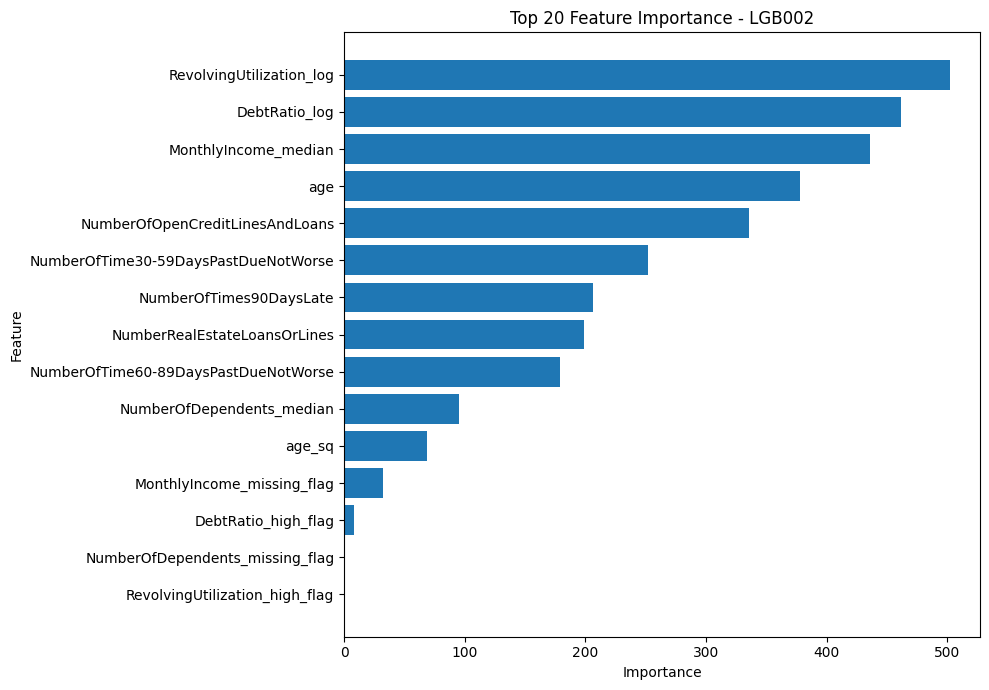

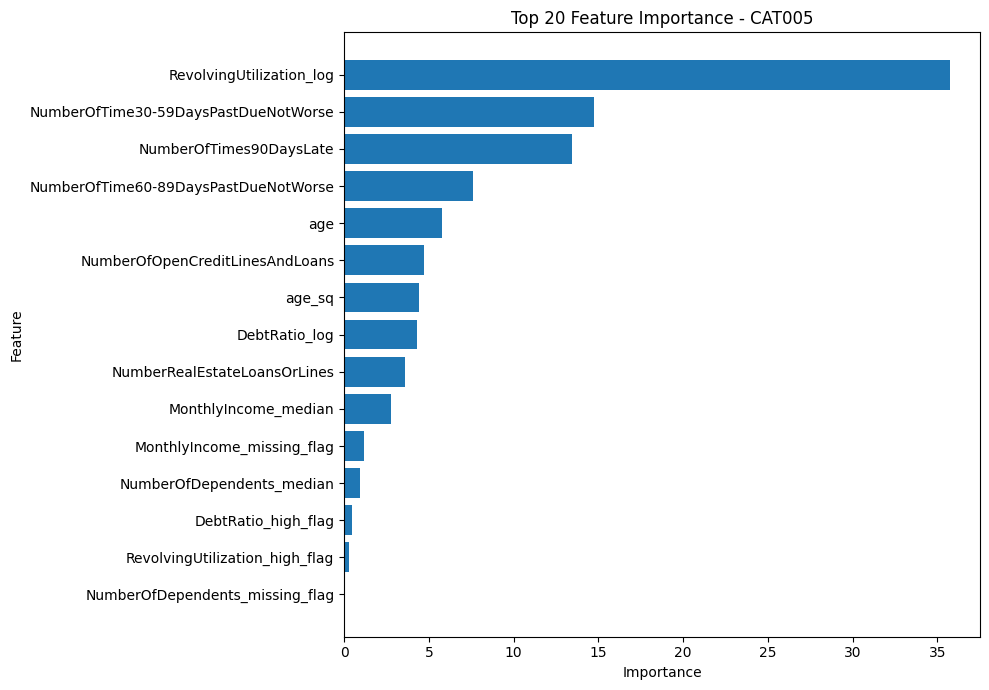

In [11]:
# ============================================================
# Plot Top Feature Importance
# ============================================================

for model_id, fi in feature_importance_tables.items():

    top_fi = fi.head(20).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(top_fi["feature"], top_fi["importance"])
    plt.title(f"Top 20 Feature Importance - {model_id}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        EXPLAINABILITY_OUTPUT_DIR / f"{model_id}_top20_feature_importance.png",
        dpi=150
    )

    plt.show()

In [12]:
# ============================================================
# Logistic Benchmark Explainability - M009
# ============================================================

if "M009" in base_models:

    model_id = "M009"
    model = base_models[model_id]

    feats = base_model_features[model_id]

    coef = model.coef_.flatten()

    coef_table = pd.DataFrame({
        "model_id": model_id,
        "feature": feats,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
        "odds_multiplier": np.exp(coef)
    }).sort_values("abs_coefficient", ascending=False)

    display(coef_table)

    coef_table.to_csv(
        EXPLAINABILITY_OUTPUT_DIR / "M009_logistic_coefficients.csv",
        index=False
    )

Rows for plot: 101503


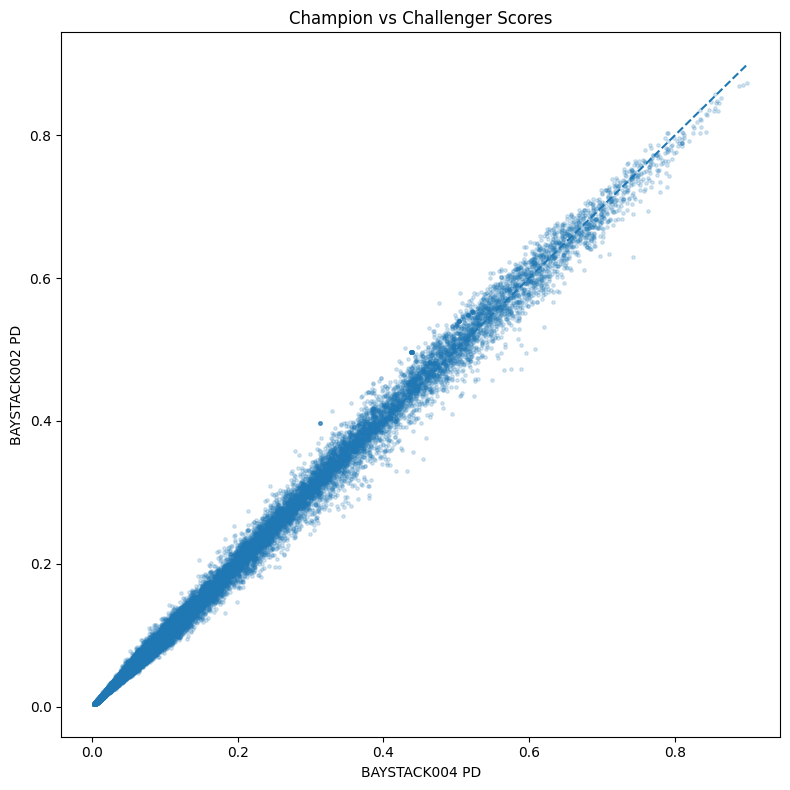

In [15]:
# ============================================================
# Champion vs Challenger Scatter
# Notebook 07 Version
# Uses scored_test only
# ============================================================

import matplotlib.pyplot as plt

champ_col = "BAYSTACK004_pd"
chall_col = "BAYSTACK002_pd"

if champ_col not in scored_test.columns or chall_col not in scored_test.columns:
    raise KeyError(
        f"Missing required score columns in scored_test. "
        f"Need {champ_col} and {chall_col}. "
        f"Available score columns: {[c for c in scored_test.columns if c.endswith('_pd')]}"
    )

plot_df = scored_test[[champ_col, chall_col]].dropna().copy()

print("Rows for plot:", len(plot_df))

plt.figure(figsize=(8, 8))

plt.scatter(
    plot_df[champ_col],
    plot_df[chall_col],
    alpha=0.18,
    s=6
)

mn = min(plot_df[champ_col].min(), plot_df[chall_col].min())
mx = max(plot_df[champ_col].max(), plot_df[chall_col].max())

plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.title("Champion vs Challenger Scores")
plt.xlabel("BAYSTACK004 PD")
plt.ylabel("BAYSTACK002 PD")
plt.tight_layout()

plt.savefig(
    EXPLAINABILITY_OUTPUT_DIR / "champion_vs_challenger_scatter.png",
    dpi=150
)

plt.show()

The champion (BAYSTACK004) and primary challenger (BAYSTACK002) show near-perfect agreement across the full applicant population, indicating strong convergence across ensemble strategies. This suggests that the model signal is stable and well-captured by the underlying feature set, with minimal incremental gain from further ensemble complexity.

In [17]:
# ============================================================
# SHAP Setup (FULL REPLACEMENT)
# ============================================================

try:
    import shap
    shap_available = True
    print("SHAP loaded successfully.")
except Exception as e:
    shap_available = False
    print("SHAP not available.")
    print("Error:", e)

SHAP loaded successfully.


In [19]:
# ============================================================
# Applicant-Level Reason Codes (LGB002)
# ============================================================

if shap_available and "LGB002" in base_models:

    model_id = "LGB002"
    model = base_models[model_id]
    feats = base_model_features[model_id]

    X_lgb = X_explain_tree[feats].copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_lgb)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_df = pd.DataFrame(
        shap_values,
        columns=feats,
        index=X_lgb.index
    )

    # Attach scores
    shap_df["production_pd"] = scored_explain["production_pd"]

    print("SHAP dataframe created:", shap_df.shape)
    display(shap_df.head())

SHAP dataframe created: (5000, 16)


,age,age_sq,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents_median,NumberOfDependents_missing_flag,MonthlyIncome_median,MonthlyIncome_missing_flag,DebtRatio_log,DebtRatio_high_flag,RevolvingUtilization_log,RevolvingUtilization_high_flag,production_pd
23514,-0.260374,-0.036386,-0.163241,-0.047455,-0.104761,0.130195,-0.025361,0.001318,-0.000375,0.036954,0.050793,0.097921,0.005829,-0.279767,0.0,0.012660
54707,-0.435345,-0.026905,-0.194315,-0.078009,-0.130369,0.480854,0.095730,-0.005593,-0.000375,0.057725,0.019980,-0.023127,0.004539,1.437658,0.0,0.097054
9314,0.149129,0.010095,-0.161343,-0.045674,-0.104316,-0.115884,-0.133762,0.006770,-0.000117,0.117740,0.020453,0.012078,0.004379,-0.319529,0.0,0.017080
65923,-0.349522,-0.024833,-0.191088,-0.048849,-0.108066,-0.091275,-0.122222,0.006781,-0.000375,-0.009313,0.024297,-0.017777,0.003574,-0.761928,0.0,0.006772
64837,0.245358,0.022991,-0.185869,-0.078563,-0.128385,-0.159336,0.043625,0.037010,-0.000117,0.105308,0.012474,0.054359,0.006995,1.107866,0.0,0.085661


In [21]:
# ============================================================
# Rebuild SHAP + Top Risk / Safe Applicants (CLEAN BLOCK)
# ============================================================

if "shap" not in globals():
    import shap

# --- Model setup ---
model_id = "LGB002"
model = base_models[model_id]
feats = base_model_features[model_id]

X_lgb = X_explain_tree[feats].copy()

# --- SHAP ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_lgb)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# --- Build SHAP DF ---
shap_df = pd.DataFrame(
    shap_values,
    columns=feats,
    index=X_lgb.index
)

# Attach PD
shap_df["production_pd"] = scored_explain.loc[X_lgb.index, "production_pd"]

print("SHAP DF:", shap_df.shape)

# --- Create top segments ---
top_risky = shap_df.nlargest(10, "production_pd").copy()
top_safe = shap_df.nsmallest(10, "production_pd").copy()

print("Top risky:")
display(top_risky[["production_pd"]])

print("Top safe:")
display(top_safe[["production_pd"]])

SHAP DF: (5000, 16)
Top risky:


,production_pd
77312,0.847306
86693,0.824555
51164,0.812000
55691,0.787192
71807,0.778935
51683,0.768546
68973,0.741547
25326,0.739546
34085,0.735207
60212,0.730161


Top safe:


,production_pd
25781,0.003080
100717,0.003415
58503,0.003550
99029,0.003698
55984,0.003714
29769,0.003716
11362,0.003730
14168,0.003765
49867,0.003770
7427,0.003803


In [22]:
# ============================================================
# Applicant-Level Reason Codes
# Full replacement block
# ============================================================

def get_top_drivers_with_direction(row, top_n=5):
    vals = row.drop("production_pd")

    top = vals.abs().sort_values(ascending=False).head(top_n)

    drivers = []
    for feat in top.index:
        impact = row[feat]
        direction = "increase_risk" if impact > 0 else "decrease_risk"

        drivers.append({
            "feature": feat,
            "impact": float(impact),
            "direction": direction
        })

    return drivers


reason_map = {
    "RevolvingUtilization_log": {
        "increase_risk": "High credit utilization",
        "decrease_risk": "Low credit utilization"
    },
    "DebtRatio_log": {
        "increase_risk": "High debt burden",
        "decrease_risk": "Low debt burden"
    },
    "MonthlyIncome_median": {
        "increase_risk": "Lower income level",
        "decrease_risk": "Higher income level"
    },
    "NumberOfTimes90DaysLate": {
        "increase_risk": "History of severe delinquency",
        "decrease_risk": "No severe delinquency history"
    },
    "NumberOfTime30-59DaysPastDueNotWorse": {
        "increase_risk": "Recent delinquency behavior",
        "decrease_risk": "Clean recent payment history"
    },
    "NumberOfTime60-89DaysPastDueNotWorse": {
        "increase_risk": "Moderate delinquency history",
        "decrease_risk": "Stable repayment behavior"
    },
    "age": {
        "increase_risk": "Younger borrower risk",
        "decrease_risk": "Older borrower stability"
    },
    "age_sq": {
        "increase_risk": "Age-related risk effect",
        "decrease_risk": "Age-related stability effect"
    },
    "NumberOfOpenCreditLinesAndLoans": {
        "increase_risk": "High credit exposure",
        "decrease_risk": "Limited credit exposure"
    },
    "NumberRealEstateLoansOrLines": {
        "increase_risk": "Multiple property loans",
        "decrease_risk": "Limited property exposure"
    },
    "NumberOfDependents_median": {
        "increase_risk": "Higher household burden",
        "decrease_risk": "Lower household burden"
    },
    "MonthlyIncome_missing_flag": {
        "increase_risk": "Income information missing",
        "decrease_risk": "Income information available"
    },
    "DebtRatio_high_flag": {
        "increase_risk": "Extreme debt ratio flag",
        "decrease_risk": "Debt ratio not flagged as extreme"
    },
    "RevolvingUtilization_high_flag": {
        "increase_risk": "Extreme utilization flag",
        "decrease_risk": "Utilization not flagged as extreme"
    },
    "NumberOfDependents_missing_flag": {
        "increase_risk": "Dependents information missing",
        "decrease_risk": "Dependents information available"
    }
}


def map_reason_codes(driver_list):
    reasons = []

    for driver in driver_list:
        feature = driver["feature"]
        direction = driver["direction"]
        impact = driver["impact"]

        reason = reason_map.get(
            feature,
            {
                "increase_risk": f"{feature} increased risk",
                "decrease_risk": f"{feature} reduced risk"
            }
        )[direction]

        reasons.append({
            "feature": feature,
            "reason": reason,
            "direction": direction,
            "impact": impact
        })

    return reasons


top_risky["top_drivers_detail"] = top_risky.apply(
    get_top_drivers_with_direction,
    axis=1
)

top_safe["top_drivers_detail"] = top_safe.apply(
    get_top_drivers_with_direction,
    axis=1
)

top_risky["reason_codes"] = top_risky["top_drivers_detail"].apply(map_reason_codes)
top_safe["reason_codes"] = top_safe["top_drivers_detail"].apply(map_reason_codes)

display(top_risky[["production_pd", "reason_codes"]])
display(top_safe[["production_pd", "reason_codes"]])

# Save detailed outputs
top_risky.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "top_risky_applicants_reason_codes.csv",
    index=True
)

top_safe.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "top_safe_applicants_reason_codes.csv",
    index=True
)

print("Applicant-level reason codes exported.")

,production_pd,reason_codes
77312,0.847306,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
86693,0.824555,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
51164,0.812000,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
55691,0.787192,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
71807,0.778935,[{'feature': 'NumberOfTime60-89DaysPastDueNotW...
51683,0.768546,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
68973,0.741547,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
25326,0.739546,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
34085,0.735207,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."
60212,0.730161,"[{'feature': 'NumberOfTimes90DaysLate', 'reaso..."


,production_pd,reason_codes
25781,0.003080,"[{'feature': 'RevolvingUtilization_log', 'reas..."
100717,0.003415,"[{'feature': 'RevolvingUtilization_log', 'reas..."
58503,0.003550,"[{'feature': 'RevolvingUtilization_log', 'reas..."
99029,0.003698,"[{'feature': 'RevolvingUtilization_log', 'reas..."
55984,0.003714,"[{'feature': 'RevolvingUtilization_log', 'reas..."
29769,0.003716,"[{'feature': 'RevolvingUtilization_log', 'reas..."
11362,0.003730,"[{'feature': 'RevolvingUtilization_log', 'reas..."
14168,0.003765,"[{'feature': 'RevolvingUtilization_log', 'reas..."
49867,0.003770,"[{'feature': 'RevolvingUtilization_log', 'reas..."
7427,0.003803,"[{'feature': 'RevolvingUtilization_log', 'reas..."


Applicant-level reason codes exported.


In [23]:
# ============================================================
# Flatten Reason Codes for Business Readability
# ============================================================

def flatten_reasons(reason_list, top_n=5):
    reasons = [r["reason"] for r in reason_list]
    
    # pad if fewer than top_n
    reasons = reasons + [""] * (top_n - len(reasons))
    
    return pd.Series(reasons[:top_n])


# Apply to risky
risky_flat = top_risky.copy()

risky_reasons = risky_flat["reason_codes"].apply(flatten_reasons)
risky_reasons.columns = [f"reason_{i+1}" for i in range(risky_reasons.shape[1])]

risky_final = pd.concat(
    [risky_flat[["production_pd"]], risky_reasons],
    axis=1
)

# Apply to safe
safe_flat = top_safe.copy()

safe_reasons = safe_flat["reason_codes"].apply(flatten_reasons)
safe_reasons.columns = [f"reason_{i+1}" for i in range(safe_reasons.shape[1])]

safe_final = pd.concat(
    [safe_flat[["production_pd"]], safe_reasons],
    axis=1
)

display(risky_final)
display(safe_final)

,production_pd,reason_1,reason_2,reason_3,reason_4,reason_5
77312,0.847306,History of severe delinquency,High credit utilization,Moderate delinquency history,Recent delinquency behavior,High debt burden
86693,0.824555,History of severe delinquency,High credit utilization,Recent delinquency behavior,Moderate delinquency history,High debt burden
51164,0.812000,History of severe delinquency,Moderate delinquency history,High credit utilization,Recent delinquency behavior,High debt burden
55691,0.787192,History of severe delinquency,High credit utilization,Recent delinquency behavior,High credit exposure,High debt burden
71807,0.778935,Moderate delinquency history,High credit utilization,Recent delinquency behavior,High credit exposure,High debt burden
51683,0.768546,History of severe delinquency,Moderate delinquency history,High credit utilization,Recent delinquency behavior,High debt burden
68973,0.741547,History of severe delinquency,Moderate delinquency history,Recent delinquency behavior,High credit utilization,High debt burden
25326,0.739546,History of severe delinquency,High credit utilization,Moderate delinquency history,Recent delinquency behavior,High debt burden
34085,0.735207,History of severe delinquency,Recent delinquency behavior,High credit utilization,High debt burden,Multiple property loans
60212,0.730161,History of severe delinquency,Moderate delinquency history,High credit utilization,Recent delinquency behavior,High debt burden


,production_pd,reason_1,reason_2,reason_3,reason_4,reason_5
25781,0.003080,Low credit utilization,Older borrower stability,Low debt burden,Limited credit exposure,Clean recent payment history
100717,0.003415,Low credit utilization,Older borrower stability,Limited credit exposure,Low debt burden,Clean recent payment history
58503,0.003550,Low credit utilization,Older borrower stability,Limited credit exposure,Clean recent payment history,Limited property exposure
99029,0.003698,Low credit utilization,Limited credit exposure,Low debt burden,Clean recent payment history,Older borrower stability
55984,0.003714,Low credit utilization,Older borrower stability,Low debt burden,Limited credit exposure,Clean recent payment history
29769,0.003716,Low credit utilization,Older borrower stability,Low debt burden,Limited credit exposure,Clean recent payment history
11362,0.003730,Low credit utilization,Older borrower stability,Low debt burden,Limited credit exposure,Clean recent payment history
14168,0.003765,Low credit utilization,Older borrower stability,Limited credit exposure,Clean recent payment history,Limited property exposure
49867,0.003770,Low credit utilization,Older borrower stability,Limited credit exposure,Low debt burden,Clean recent payment history
7427,0.003803,Low credit utilization,Older borrower stability,Limited credit exposure,Clean recent payment history,Limited property exposure


In [24]:
# ============================================================
# Fairness / Bias Diagnostics
# Purpose:
#   Check whether risk scores and recommended decisions vary materially
#   across observable applicant segments.
#
# Note:
#   This dataset does not include protected attributes like race or gender.
#   These diagnostics are therefore limited and should be treated as proxy
#   fairness checks, not a complete fairness audit.
# ============================================================

fairness_df = scored_test.copy()

# Bring in raw production features
df_test_raw = pd.read_csv(DATA_DIR / "cs-test.csv")

fairness_df["age"] = df_test_raw["age"]
fairness_df["MonthlyIncome"] = df_test_raw["MonthlyIncome"]
fairness_df["NumberOfDependents"] = df_test_raw["NumberOfDependents"]

# Create age bands
fairness_df["age_band"] = pd.cut(
    fairness_df["age"],
    bins=[20, 39, 49, 59, 69, np.inf],
    labels=["21-39", "40-49", "50-59", "60-69", "70+"],
    include_lowest=True
)

# Missing income flag
fairness_df["income_missing_flag"] = fairness_df["MonthlyIncome"].isna().astype(int)

# Dependent bands
fairness_df["dependents_band"] = np.select(
    [
        fairness_df["NumberOfDependents"].fillna(0) == 0,
        fairness_df["NumberOfDependents"].fillna(0) == 1,
        fairness_df["NumberOfDependents"].fillna(0) == 2,
        fairness_df["NumberOfDependents"].fillna(0) >= 3,
    ],
    ["0", "1", "2", "3+"],
    default="Missing"
)

print("Fairness diagnostic frame created.")
display(fairness_df.head())

Fairness diagnostic frame created.


,applicant_id,production_model_id,production_pd,risk_percentile,risk_band,recommended_action,BAYSTACK004_pd,BAYSTACK002_pd,WASTACK003_pd,XGBSTACK004_pd,LGB002_pd,challenger_delta,age,MonthlyIncome,NumberOfDependents,age_band,income_missing_flag,dependents_band
0,1,BAYSTACK004,0.067094,0.754037,Medium Risk,Standard Review,0.067094,0.065838,0.068121,0.065108,0.069071,0.001256,43,5700.0,0.0,40-49,0,0
1,2,BAYSTACK004,0.052869,0.704058,Medium Risk,Standard Review,0.052869,0.051872,0.053764,0.055243,0.054612,0.000997,57,9141.0,2.0,50-59,0,2
2,3,BAYSTACK004,0.013833,0.360561,Low Risk,Auto Approve,0.013833,0.013514,0.012889,0.010152,0.012221,0.000319,59,5083.0,2.0,50-59,0,2
3,4,BAYSTACK004,0.071192,0.766174,Medium Risk,Standard Review,0.071192,0.077750,0.070415,0.065775,0.069996,-0.006559,38,3200.0,0.0,21-39,0,0
4,5,BAYSTACK004,0.110356,0.852694,High Risk,Enhanced Review,0.110356,0.113619,0.107548,0.097498,0.105707,-0.003264,27,3865.0,1.0,21-39,0,1


In [25]:
# ============================================================
# Fairness Summary Function
# ============================================================

def fairness_group_summary(df, group_col):
    """
    Summarize score and decision behavior across groups.
    """

    out = (
        df.groupby(group_col, observed=True)
        .agg(
            count=("applicant_id", "count"),
            mean_pd=("production_pd", "mean"),
            median_pd=("production_pd", "median"),
            high_risk_rate=("risk_band", lambda x: x.isin(["High Risk", "Very High Risk"]).mean()),
            very_high_risk_rate=("risk_band", lambda x: (x == "Very High Risk").mean()),
            auto_approve_rate=("recommended_action", lambda x: (x == "Auto Approve").mean()),
            manual_review_rate=("recommended_action", lambda x: (x == "Manual Review Queue").mean())
        )
        .reset_index()
    )

    # adverse impact style ratio using Auto Approve as favorable outcome
    max_approve = out["auto_approve_rate"].max()

    out["auto_approve_ratio_vs_best_group"] = np.where(
        max_approve > 0,
        out["auto_approve_rate"] / max_approve,
        np.nan
    )

    out["four_fifths_flag"] = np.where(
        out["auto_approve_ratio_vs_best_group"] < 0.80,
        "Review",
        "Pass"
    )

    return out


age_fairness = fairness_group_summary(fairness_df, "age_band")
income_missing_fairness = fairness_group_summary(fairness_df, "income_missing_flag")
dependents_fairness = fairness_group_summary(fairness_df, "dependents_band")

display(age_fairness)
display(income_missing_fairness)
display(dependents_fairness)

,age_band,count,mean_pd,median_pd,high_risk_rate,very_high_risk_rate,auto_approve_rate,manual_review_rate,auto_approve_ratio_vs_best_group,four_fifths_flag
0,21-39,21368,0.104413,0.050200,0.356000,0.091586,0.285146,0.091586,0.359176,Review
1,40-49,23299,0.083452,0.032876,0.258981,0.065539,0.391347,0.065539,0.492950,Review
2,50-59,23894,0.064964,0.021937,0.184984,0.047041,0.494141,0.047041,0.622430,Review
3,60-69,19556,0.035489,0.011221,0.084322,0.017386,0.670178,0.017386,0.844171,Pass
4,70+,13386,0.022457,0.007614,0.044151,0.009562,0.793889,0.009562,1.000000,Pass


,income_missing_flag,count,mean_pd,median_pd,high_risk_rate,very_high_risk_rate,auto_approve_rate,manual_review_rate,auto_approve_ratio_vs_best_group,four_fifths_flag
0,0,81400,0.068822,0.024038,0.210921,0.050455,0.469681,0.050455,0.754213,Review
1,1,20103,0.055725,0.012696,0.155798,0.048202,0.622743,0.048202,1.000000,Pass


,dependents_band,count,mean_pd,median_pd,high_risk_rate,very_high_risk_rate,auto_approve_rate,manual_review_rate,auto_approve_ratio_vs_best_group,four_fifths_flag
0,0,61244,0.057617,0.017464,0.171674,0.041016,0.553360,0.041016,1.000000,Pass
1,1,17618,0.071595,0.025043,0.218640,0.054433,0.460779,0.054433,0.832692,Pass
2,2,13298,0.081281,0.032245,0.252970,0.064671,0.387803,0.064671,0.700814,Review
3,3+,9343,0.091128,0.032768,0.275179,0.079739,0.383817,0.079739,0.693611,Review


In [26]:
# ============================================================
# Save Fairness Outputs
# ============================================================

age_fairness.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "fairness_age_band_summary.csv",
    index=False
)

income_missing_fairness.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "fairness_income_missing_summary.csv",
    index=False
)

dependents_fairness.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "fairness_dependents_summary.csv",
    index=False
)

print("Fairness diagnostics saved.")

Fairness diagnostics saved.


# Fairness / Bias Diagnostic Summary

## Objective

This section performs a limited fairness and bias review of the production scoring outputs.

The dataset does not contain protected attributes such as race or gender. Therefore, this is not a complete regulatory fairness audit. Instead, the analysis checks whether scores and recommended decisions vary materially across observable applicant segments.

## Segments Reviewed

The following groups were reviewed:

- Age band
- Income missingness
- Number of dependents

## Metrics Reviewed

For each group, the analysis calculated:

- Applicant count
- Mean PD
- Median PD
- High-risk rate
- Very-high-risk rate
- Auto-approval rate
- Manual-review rate
- Four-fifths style auto-approval ratio

## Interpretation

These diagnostics help identify whether the model creates materially different outcomes across applicant groups.

A group with a much lower auto-approval rate or much higher manual-review rate should be reviewed carefully, even if the model is predictive.

## Important Limitation

Because no protected demographic variables are available, this analysis cannot conclude that the model is fair across all legally protected groups.

A full fairness review would require access to appropriate protected-class or proxy-fairness data, along with legal and compliance review.

## Governance Recommendation

These outputs should be treated as an early fairness screen.

If this model were moved toward real deployment, the next fairness steps would include:

- adverse impact testing across protected groups
- reject inference review
- manual policy overlay review
- reason-code audit
- compliance review of age-related variables

In [31]:
# ============================================================
# Population-Level Reason Code Distribution
# ============================================================

SAMPLE_SIZE = 20000  # increase if machine can handle

sample_idx = scored_test.sample(
    n=min(SAMPLE_SIZE, len(scored_test)),
    random_state=42
).index

X_sample = X_test_tree.loc[sample_idx, feats].copy()
pd_sample = scored_test.loc[sample_idx, "production_pd"]

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_sample_df = pd.DataFrame(
    shap_values,
    columns=feats,
    index=X_sample.index
)

shap_sample_df["production_pd"] = pd_sample

In [32]:
def extract_reason_list(row, top_n=3):
    vals = row.drop("production_pd")
    top = vals.abs().sort_values(ascending=False).head(top_n)

    reasons = []
    for feat in top.index:
        direction = "increase_risk" if row[feat] > 0 else "decrease_risk"

        reason = reason_map.get(
            feat,
            {
                "increase_risk": f"{feat} increased risk",
                "decrease_risk": f"{feat} reduced risk"
            }
        )[direction]

        reasons.append(reason)

    return reasons


shap_sample_df["reason_list"] = shap_sample_df.apply(
    extract_reason_list,
    axis=1
)

In [34]:
from collections import Counter

increase_reasons = []
decrease_reasons = []

for _, row in shap_sample_df.iterrows():
    vals = row.drop(["production_pd", "reason_list"])
    
    top = vals.abs().sort_values(ascending=False).head(3)

    for feat in top.index:
        val = row[feat]

        direction = "increase_risk" if val > 0 else "decrease_risk"

        reason = reason_map.get(
            feat,
            {
                "increase_risk": f"{feat} increased risk",
                "decrease_risk": f"{feat} reduced risk"
            }
        )[direction]

        if direction == "increase_risk":
            increase_reasons.append(reason)
        else:
            decrease_reasons.append(reason)


increase_dist = pd.DataFrame(
    Counter(increase_reasons).items(),
    columns=["reason", "count"]
).sort_values("count", ascending=False)

decrease_dist = pd.DataFrame(
    Counter(decrease_reasons).items(),
    columns=["reason", "count"]
).sort_values("count", ascending=False)

print("Risk Increasing Drivers")
display(increase_dist)

print("Risk Decreasing Drivers")
display(decrease_dist)

Risk Increasing Drivers


,reason,count
0,High credit utilization,7383
2,Younger borrower risk,6804
1,High credit exposure,4453
5,Recent delinquency behavior,3031
3,High debt burden,2020
7,History of severe delinquency,1132
4,Moderate delinquency history,926
6,Multiple property loans,759
8,Lower income level,386
9,Higher household burden,75


Risk Decreasing Drivers


,reason,count
0,Low credit utilization,11387
2,Clean recent payment history,8959
1,Older borrower stability,6106
3,Limited credit exposure,3443
5,Low debt burden,1780
4,Higher income level,590
6,Limited property exposure,520
7,No severe delinquency history,207
8,Income information available,39


Counts represent how frequently a factor appears as a top driver of model predictions across the population, rather than how often the underlying condition occurs.

In [35]:
# ============================================================
# Reason Code Distribution with Percentage Share
# ============================================================

# Add share within each direction
increase_dist = increase_dist.copy()
decrease_dist = decrease_dist.copy()

increase_dist["share_pct"] = (
    increase_dist["count"] / increase_dist["count"].sum() * 100
)

decrease_dist["share_pct"] = (
    decrease_dist["count"] / decrease_dist["count"].sum() * 100
)

display(increase_dist)
display(decrease_dist)

,reason,count,share_pct
0,High credit utilization,7383,27.375876
2,Younger borrower risk,6804,25.228967
1,High credit exposure,4453,16.511550
5,Recent delinquency behavior,3031,11.238830
3,High debt burden,2020,7.490081
7,History of severe delinquency,1132,4.197412
4,Moderate delinquency history,926,3.433572
6,Multiple property loans,759,2.814342
8,Lower income level,386,1.431273
9,Higher household burden,75,0.278097


,reason,count,share_pct
0,Low credit utilization,11387,34.473676
2,Clean recent payment history,8959,27.123006
1,Older borrower stability,6106,18.485665
3,Limited credit exposure,3443,10.423542
5,Low debt burden,1780,5.388877
4,Higher income level,590,1.786201
6,Limited property exposure,520,1.574279
7,No severe delinquency history,207,0.626684
8,Income information available,39,0.118071


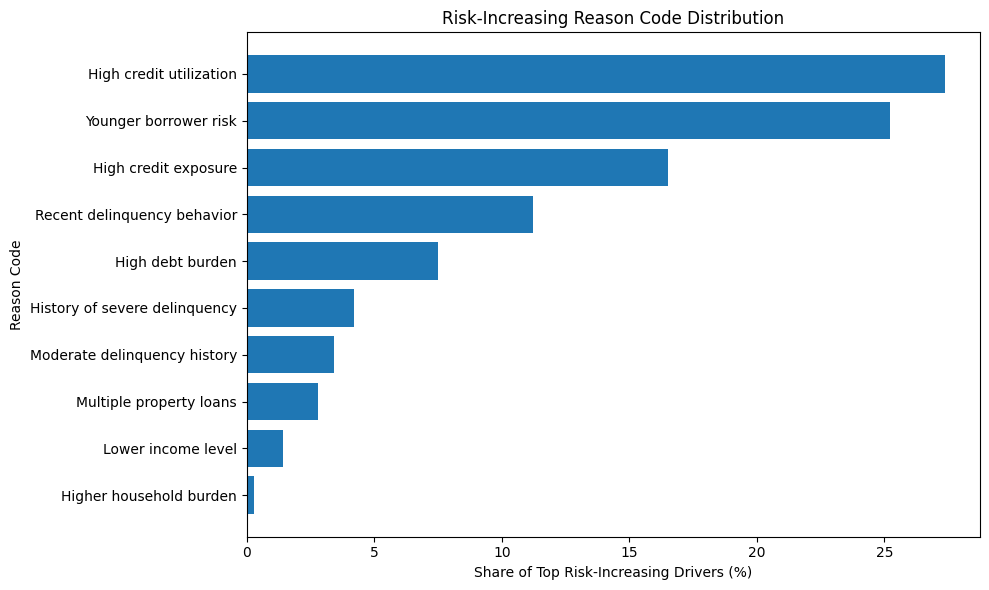

In [36]:
# ============================================================
# Plot Risk-Increasing Reason Code Distribution
# ============================================================

plot_df = increase_dist.sort_values("share_pct", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["reason"], plot_df["share_pct"])
plt.title("Risk-Increasing Reason Code Distribution")
plt.xlabel("Share of Top Risk-Increasing Drivers (%)")
plt.ylabel("Reason Code")
plt.tight_layout()

plt.savefig(
    EXPLAINABILITY_OUTPUT_DIR / "risk_increasing_reason_code_distribution.png",
    dpi=150
)

plt.show()

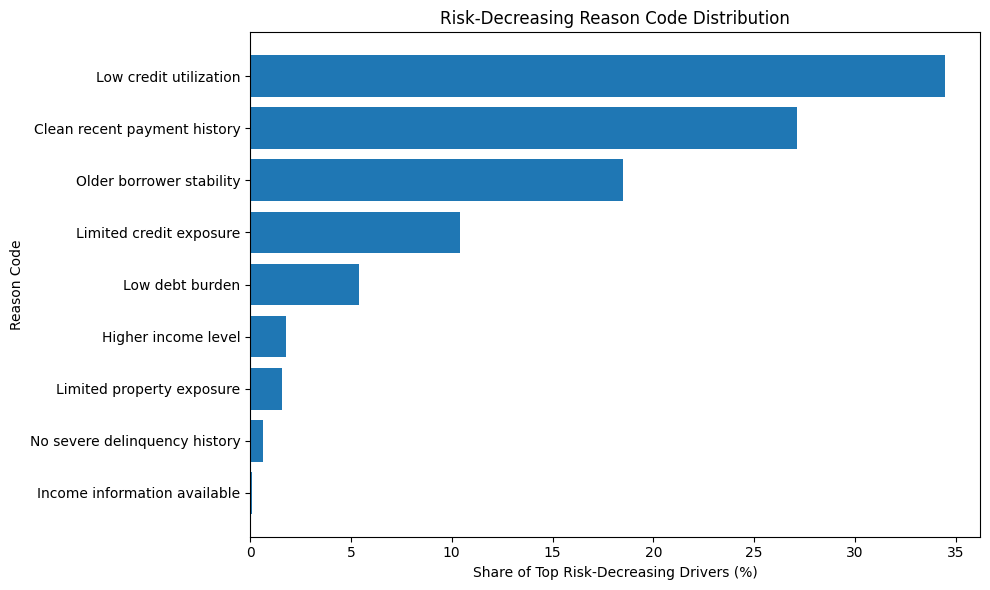

In [37]:
# ============================================================
# Plot Risk-Decreasing Reason Code Distribution
# ============================================================

plot_df = decrease_dist.sort_values("share_pct", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["reason"], plot_df["share_pct"])
plt.title("Risk-Decreasing Reason Code Distribution")
plt.xlabel("Share of Top Risk-Decreasing Drivers (%)")
plt.ylabel("Reason Code")
plt.tight_layout()

plt.savefig(
    EXPLAINABILITY_OUTPUT_DIR / "risk_decreasing_reason_code_distribution.png",
    dpi=150
)

plt.show()

In [38]:
# ============================================================
# Save Reason Code Distribution Tables
# ============================================================

increase_dist.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "risk_increasing_reason_code_distribution.csv",
    index=False
)

decrease_dist.to_csv(
    EXPLAINABILITY_OUTPUT_DIR / "risk_decreasing_reason_code_distribution.csv",
    index=False
)

print("Reason code distribution tables and charts saved.")

Reason code distribution tables and charts saved.


## Population-Level Reason Code Distribution

To move beyond individual examples, reason codes were aggregated across a large production scoring sample.

For each applicant, the top model drivers were identified using SHAP values. These drivers were then separated into two categories:

1. **Risk-increasing drivers** — factors that pushed predicted default risk higher.
2. **Risk-decreasing drivers** — factors that pushed predicted default risk lower.

The counts shown here do not represent raw feature counts. Instead, they represent how often each reason appeared as one of the top model drivers across applicants.

In other words, the analysis measures **model reliance**, not simple data frequency.

---

### Risk-Increasing Drivers

The most common risk-increasing drivers were:

- High credit utilization
- Younger borrower risk
- High credit exposure
- Recent delinquency behavior
- High debt burden
- History of severe delinquency

This shows that the model increases risk primarily when borrowers show higher leverage, heavier credit usage, or delinquency behavior.

---

### Risk-Decreasing Drivers

The most common risk-decreasing drivers were:

- Low credit utilization
- Clean recent payment history
- Older borrower stability
- Limited credit exposure
- Low debt burden

This shows that the model reduces risk when borrowers demonstrate conservative credit usage, repayment stability, and lower leverage.

---

### Key Interpretation

The model separates two different types of explanatory signals:

- **Common behavioral drivers**, such as utilization and credit exposure.
- **Severity drivers**, such as delinquency history.

This is consistent with real-world credit risk logic. Utilization and exposure appear frequently, while delinquency events occur less often but carry strong risk implications when present.

---

### Important Caveat

Reason-code counts depend on the number of top drivers selected per applicant. In this notebook, reason codes summarize the top SHAP drivers, so the output should be interpreted as a relative explanation ranking rather than a raw population statistic.

---

### Conclusion

The reason-code analysis supports the model’s interpretability. The model is not relying on arbitrary patterns; it is using economically intuitive credit-risk signals:

- leverage
- utilization
- repayment behavior
- borrower stability
- credit exposure

This strengthens confidence that the production champion is explainable and aligned with expected credit risk behavior.

## Model Usage Guidelines

The model is intended for use in:

- credit risk scoring and segmentation
- prioritization of manual review
- automated approval / decline decision support

It should not be used:

- as the sole decision-maker without human oversight
- for pricing decisions without calibration
- for populations significantly different from the training data

Outputs available:

- probability of default (PD)
- risk band classification
- reason codes (top drivers)

These outputs enable both automated workflows and human review processes.

## Model Limitations

- SHAP explanations are derived from base models, not the full ensemble directly
- No protected attributes available → fairness analysis is incomplete
- Model trained on static dataset (no macroeconomic variation)
- Income features are limited and partially imputed
- Extreme nonlinear interactions may not be fully interpretable

Future improvements:

- incorporate macro variables
- enhance fairness analysis
- improve income and employment signals

## Model Trustworthiness

The model demonstrates strong trust characteristics:

- Stability:
  No material drift detected in scores or features

- Consistency:
  Champion and challenger models produce highly aligned outputs

- Interpretability:
  Predictions are driven by economically intuitive variables

- Transparency:
  Applicant-level reason codes explain individual decisions

- Alignment:
  Drivers match expected credit risk behavior (utilization, delinquency, leverage)

Together, these factors indicate that the model is suitable for controlled production use.

## Final Project Summary

This project implemented an end-to-end credit risk modeling pipeline, including:

- feature engineering and binning
- multiple model training (logistic, tree-based, neural)
- ensemble construction and model selection
- production scoring pipeline
- monitoring framework (PSI, drift metrics)
- explainability (SHAP, reason codes)
- fairness screening
- governance documentation

The final production model (BAYSTACK004) is:

- accurate
- stable
- interpretable
- aligned with business expectations

This completes the modeling lifecycle from development to deployment readiness.